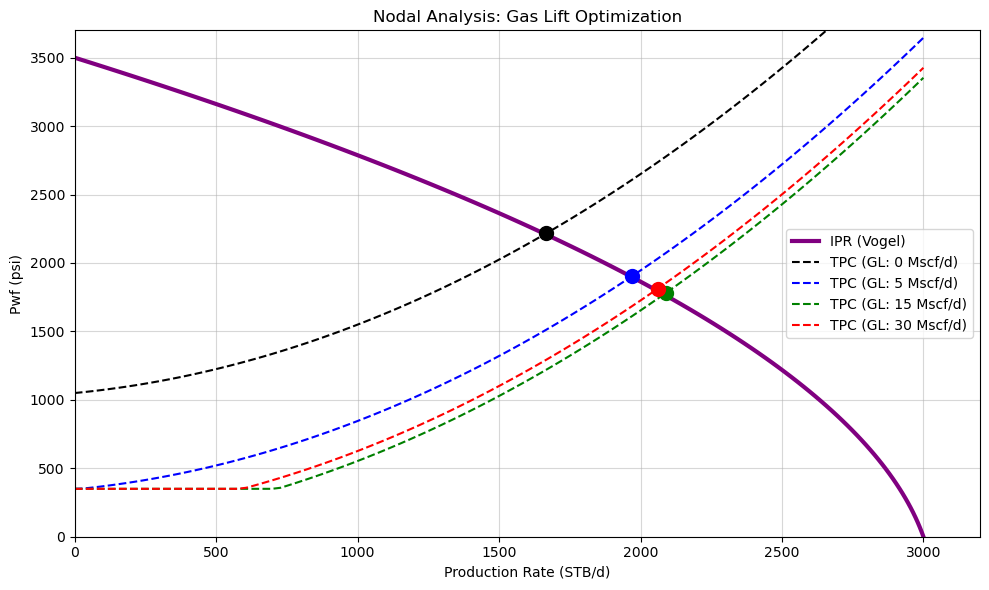

Gas Lift Optimization Results:
Inj: 0 Mscf/d | Prod: 1667 STB/d
Inj: 5 Mscf/d | Prod: 1970 STB/d
Inj: 15 Mscf/d | Prod: 2091 STB/d
Inj: 30 Mscf/d | Prod: 2061 STB/d


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# well and reservoir base params
P_R = 3500       # res pressure (psi)
q_max = 3000     # AOF (STB/d)
P_wh = 250       # wellhead pressure (psi)

# vogel's two-phase IPR
def vogel_ipr(pwf, pr, qmax):
    return qmax * (1 - 0.2 * (pwf / pr) - 0.8 * (pwf / pr)**2)

pwf_array = np.linspace(0, P_R, 100)
q_ipr = vogel_ipr(pwf_array, P_R, q_max)

# simplified VLP / tubing performance curve
def tpc_model(q, gas_inj_rate):
    base_pwf = P_wh + (800 + 0.2 * q + 0.0003 * q**2)
    
    # gas injection balances hydrostatic drop vs friction gain
    hydrostatic_reduction = 400 * np.log1p(gas_inj_rate)
    friction_penalty = 0.5 * gas_inj_rate**2
    
    return np.maximum(base_pwf - hydrostatic_reduction + friction_penalty, P_wh + 100)

gas_injection_rates = [0, 5, 15, 30] # Mscf/d
colors = ['black', 'blue', 'green', 'red']

# plot setup and find operating points
plt.figure(figsize=(10, 6))
plt.plot(q_ipr, pwf_array, label='IPR (Vogel)', color='purple', linewidth=3)

operating_rates = []

for gl_rate, color in zip(gas_injection_rates, colors):
    q_tpc = np.linspace(0, q_max, 100)
    pwf_tpc = tpc_model(q_tpc, gl_rate)
    
    plt.plot(q_tpc, pwf_tpc, label=f'TPC (GL: {gl_rate} Mscf/d)', color=color, linestyle='--')
    
    # find intersection
    interpolated_ipr_pwf = np.interp(q_tpc, q_ipr[::-1], pwf_array[::-1])
    diff = np.abs(interpolated_ipr_pwf - pwf_tpc)
    idx = np.argmin(diff)
    
    op_q = q_tpc[idx]
    op_pwf = pwf_tpc[idx]
    operating_rates.append((gl_rate, op_q))
    
    plt.scatter(op_q, op_pwf, color=color, s=100, zorder=5)

plt.title('Nodal Analysis: Gas Lift Optimization')
plt.xlabel('Production Rate (STB/d)')
plt.ylabel('Pwf (psi)')
plt.xlim(0, q_max + 200)
plt.ylim(0, P_R + 200)
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# print results
print("Gas Lift Optimization Results:")
for rate, prod in operating_rates:
    print(f"Inj: {rate} Mscf/d | Prod: {prod:.0f} STB/d")